In [13]:
import pandas as pd

df = pd.read_csv('/superstore_final_dataset (1).csv', encoding='latin1')

print(df.head())

   Row_ID        Order_ID  Order_Date   Ship_Date       Ship_Mode Customer_ID  \
0       1  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688   12/6/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer_Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3    Sean O Donnel   Consumer  United States  Fort Lauderdale     Florida   
4    Sean O Donnel   Consumer  United States  Fort Lauderdale     Florida   

   Postal_Code Region       Product_ID         Cat

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [25]:
df.isnull().sum()

,0
Row_ID,0
Order_ID,0
Order_Date,0
Ship_Date,0
Ship_Mode,0
Customer_ID,0
Customer_Name,0
Segment,0
Country,0
City,0


In [26]:
df.describe()

,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [27]:
print("Total Sales =", df['Sales'].sum())

Total Sales = 2261536.7827000003


In [29]:
print(df.columns)

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='object')


In [30]:
total_orders = df['Order_ID'].nunique()

print("Total Orders =", total_orders)

Total Orders = 4922


In [31]:
total_sales = df['Sales'].sum()
total_orders = df['Order_ID'].nunique()

aov = total_sales / total_orders

print("Average Order Value =", round(aov, 2))

Average Order Value = 459.48


Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


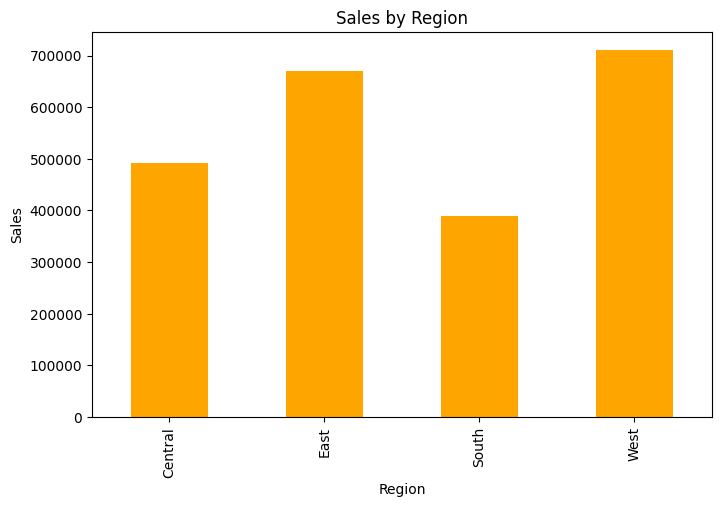

In [32]:
import matplotlib.pyplot as plt

region_sales = df.groupby('Region')['Sales'].sum()

print(region_sales)

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar', color='orange')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.show()

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


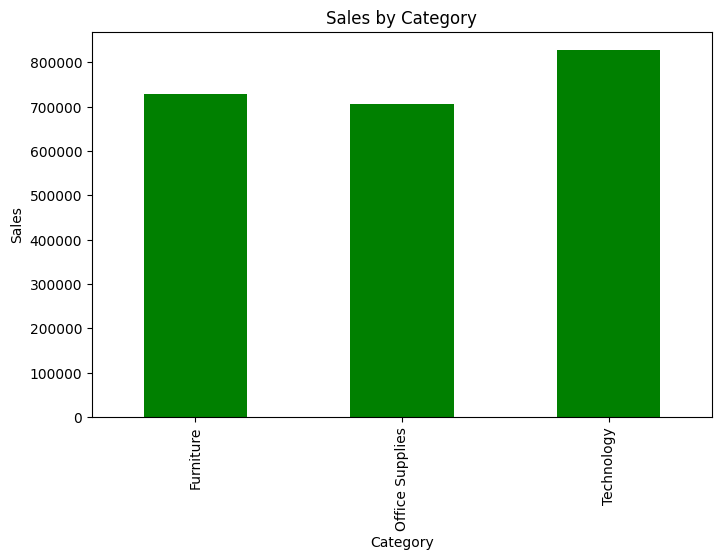

In [33]:
import matplotlib.pyplot as plt

category_sales = df.groupby('Category')['Sales'].sum()

print(category_sales)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color='green')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')

plt.show()

In [34]:
top_products = df.groupby('Product_Name')['Sales'].sum() \
                 .sort_values(ascending=False) \
                 .head(10)

print(top_products)

Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


/tmp/ipykernel_10758/4134568641.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


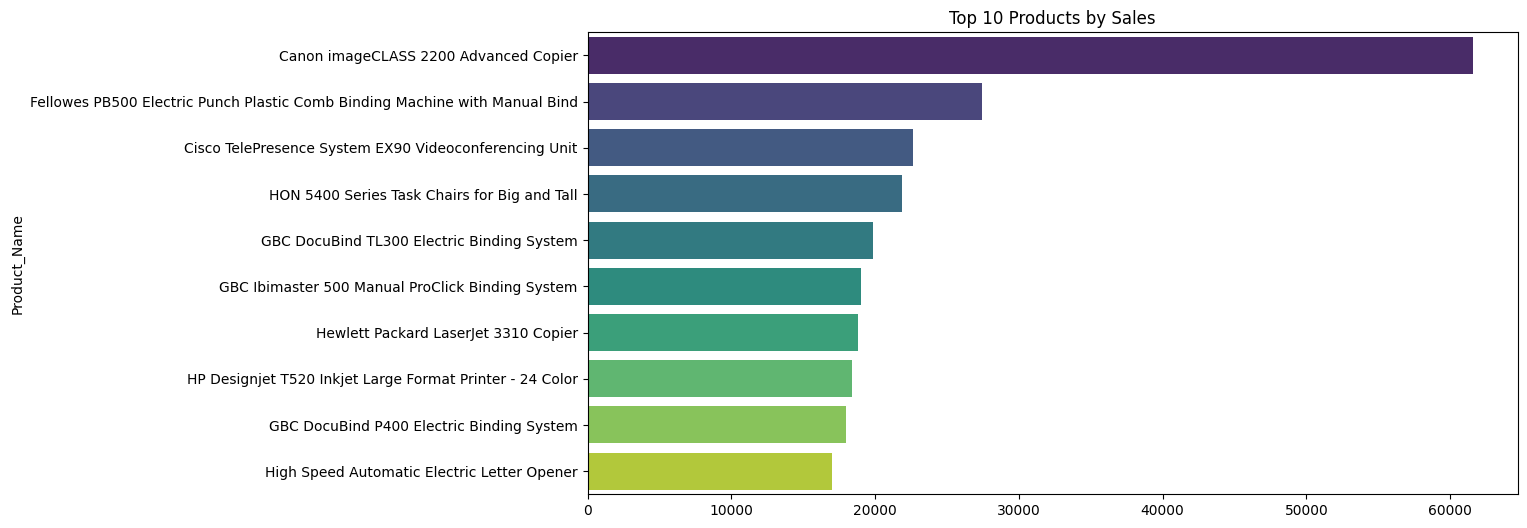

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

top_products = df.groupby('Product_Name')['Sales'].sum() \
                 .sort_values(ascending=False) \
                 .head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette='viridis'
)

plt.title('Top 10 Products by Sales')

plt.show()

Month
2015-01    19546.163
2015-02    11678.994
2015-03     6716.044
2015-04    12455.482
2015-05    15165.051
Name: Sales, dtype: float64


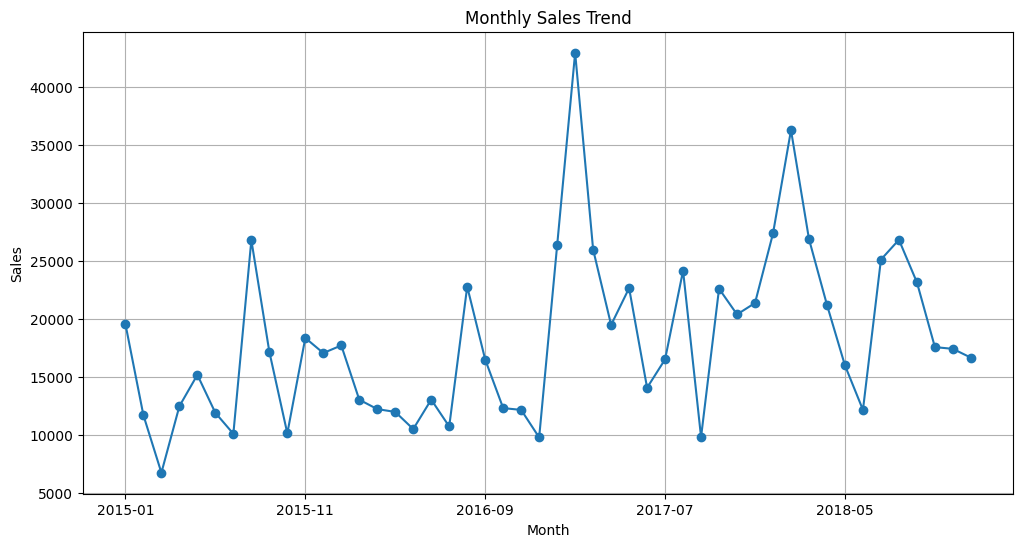

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

df['Month'] = df['Order_Date'].dt.strftime('%Y-%m')

monthly_sales = df.groupby('Month')['Sales'].sum()

print(monthly_sales.head())

plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

In [40]:
total_sales = df['Sales'].sum()
total_orders = df['Order_ID'].nunique()
aov = total_sales / total_orders

print("Total Sales =", round(total_sales,2))
print("Total Orders =", total_orders)
print("Average Order Value =", round(aov,2))

Total Sales = 2261536.78
Total Orders = 4922
Average Order Value = 459.48
